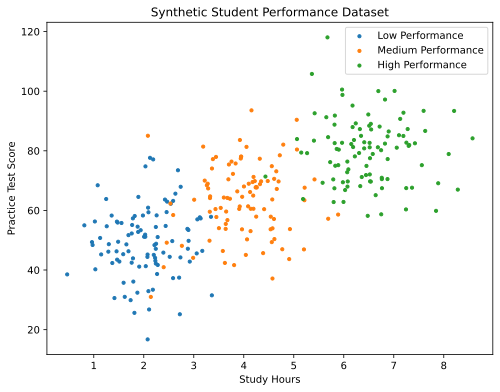

In [3]:
# Multi-Class Neural Network Example Using PyTorch
# Student Performance Classification

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")


# --------------------------------------------------
# 1. Set random seeds
# --------------------------------------------------

np.random.seed(0)
torch.manual_seed(0)


# --------------------------------------------------
# 2. Generate synthetic student performance data
# --------------------------------------------------

num_samples_per_class = 100

# Class 0: Low performance
low_study_hours = np.random.normal(2.0, 0.6, num_samples_per_class)
low_attendance = np.random.normal(55, 8, num_samples_per_class)
low_practice_score = np.random.normal(50, 12, num_samples_per_class)
low_assignment_score = np.random.normal(50, 8, num_samples_per_class)

low_performance = np.column_stack((
    low_study_hours,
    low_attendance,
    low_practice_score,
    low_assignment_score
))

low_labels = np.zeros(num_samples_per_class)


# Class 1: Medium performance
medium_study_hours = np.random.normal(4.0, 0.7, num_samples_per_class)
medium_attendance = np.random.normal(75, 7, num_samples_per_class)
medium_practice_score = np.random.normal(65, 12, num_samples_per_class)
medium_assignment_score = np.random.normal(72, 6, num_samples_per_class)

medium_performance = np.column_stack((
    medium_study_hours,
    medium_attendance,
    medium_practice_score,
    medium_assignment_score
))

medium_labels = np.ones(num_samples_per_class)


# Class 2: High performance
high_study_hours = np.random.normal(6.5, 0.8, num_samples_per_class)
high_attendance = np.random.normal(90, 5, num_samples_per_class)
high_practice_score = np.random.normal(80, 12, num_samples_per_class)
high_assignment_score = np.random.normal(90, 5, num_samples_per_class)

high_performance = np.column_stack((
    high_study_hours,
    high_attendance,
    high_practice_score,
    high_assignment_score
))

high_labels = np.full(num_samples_per_class, 2)


# --------------------------------------------------
# 3. Combine the data
# --------------------------------------------------

data = np.vstack((
    low_performance,
    medium_performance,
    high_performance
)).astype(np.float32)

labels = np.hstack((
    low_labels,
    medium_labels,
    high_labels
)).astype(np.int64)


# --------------------------------------------------
# 4. Visualize original dataset
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    low_study_hours,
    low_practice_score,
    s=10,
    label="Low Performance"
)

plt.scatter(
    medium_study_hours,
    medium_practice_score,
    s=10,
    label="Medium Performance"
)

plt.scatter(
    high_study_hours,
    high_practice_score,
    s=10,
    label="High Performance"
)

plt.xlabel("Study Hours")
plt.ylabel("Practice Test Score")
plt.title("Synthetic Student Performance Dataset")
plt.legend()
plt.show()

In [5]:

# --------------------------------------------------
# 5. Split into training and testing sets
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


# --------------------------------------------------
# 6. Standardize the features
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------------------------
# 7. Convert data to PyTorch tensors
# --------------------------------------------------

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [17]:

# --------------------------------------------------
# 8. Define the multi-class ANN model
# --------------------------------------------------

model = nn.Sequential(
    nn.Linear(4, 64),
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16, 3)
)

print(model)


Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=3, bias=True)
)


In [19]:
# --------------------------------------------------
# 9. Define loss function and optimizer
# --------------------------------------------------

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# --------------------------------------------------
# 10. Train the model
# --------------------------------------------------

num_epochs = 300

training_losses = []
training_accuracies = []
testing_accuracies = []

for epoch in range(num_epochs):

    model.train()

    # Forward pass
    train_outputs = model(X_train)

    # Compute loss
    loss = loss_function(train_outputs, y_train)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Training accuracy
    train_predictions = torch.argmax(train_outputs, dim=1)
    train_accuracy = (
        train_predictions == y_train
    ).float().mean() * 100

    # Testing accuracy
    model.eval()

    with torch.no_grad():

        test_outputs = model(X_test)

        test_predictions = torch.argmax(test_outputs, dim=1)

        test_accuracy = (
            test_predictions == y_test
        ).float().mean() * 100

    training_losses.append(loss.item())
    training_accuracies.append(train_accuracy.item())
    testing_accuracies.append(test_accuracy.item())

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train Accuracy: {train_accuracy:.2f}% | "
            f"Test Accuracy: {test_accuracy:.2f}%"
        )



Epoch   0 | Loss: 1.0972 | Train Accuracy: 33.33% | Test Accuracy: 33.33%
Epoch  50 | Loss: 0.5117 | Train Accuracy: 92.08% | Test Accuracy: 85.00%
Epoch 100 | Loss: 0.0647 | Train Accuracy: 99.17% | Test Accuracy: 100.00%
Epoch 150 | Loss: 0.0195 | Train Accuracy: 99.58% | Test Accuracy: 100.00%
Epoch 200 | Loss: 0.0103 | Train Accuracy: 100.00% | Test Accuracy: 100.00%
Epoch 250 | Loss: 0.0064 | Train Accuracy: 100.00% | Test Accuracy: 100.00%


In [20]:

# --------------------------------------------------
# 11. Final evaluation
# --------------------------------------------------

model.eval()

with torch.no_grad():

    final_train_outputs = model(X_train)
    final_test_outputs = model(X_test)

    final_train_predictions = torch.argmax(final_train_outputs, dim=1)
    final_test_predictions = torch.argmax(final_test_outputs, dim=1)

    final_train_accuracy = (
        final_train_predictions == y_train
    ).float().mean() * 100

    final_test_accuracy = (
        final_test_predictions == y_test
    ).float().mean() * 100


print()
print(f"Final Training Accuracy: {final_train_accuracy:.2f}%")
print(f"Final Testing Accuracy:  {final_test_accuracy:.2f}%")



Final Training Accuracy: 100.00%
Final Testing Accuracy:  100.00%


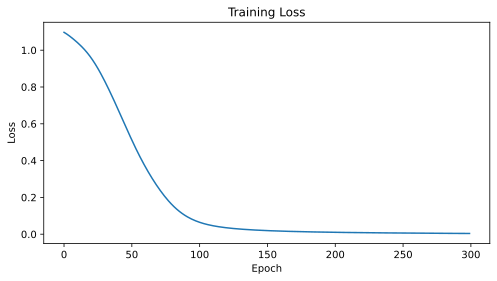

In [21]:

# --------------------------------------------------
# 12. Plot training loss
# --------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(training_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()



Confusion Matrix:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


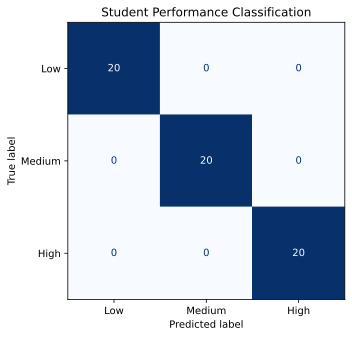


Classification Report:

                    precision    recall  f1-score   support

   Low Performance       1.00      1.00      1.00        20
Medium Performance       1.00      1.00      1.00        20
  High Performance       1.00      1.00      1.00        20

          accuracy                           1.00        60
         macro avg       1.00      1.00      1.00        60
      weighted avg       1.00      1.00      1.00        60



In [22]:
# --------------------------------------------------
# 17. Confusion Matrix and Classification Report
# --------------------------------------------------

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create confusion matrix
cm = confusion_matrix(
    y_test.numpy(),
    final_test_predictions.numpy()
)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Student Performance Classification")
plt.show()


# --------------------------------------------------
# 18. Classification Report
# --------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test.numpy(),
        final_test_predictions.numpy(),
        target_names=[
            "Low Performance",
            "Medium Performance",
            "High Performance"
        ]
    )
)

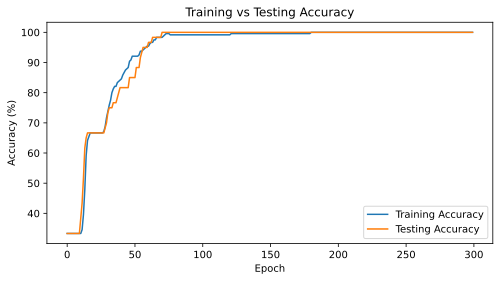

In [23]:
plt.figure(figsize=(8,4))

plt.plot(training_accuracies,
         label='Training Accuracy')

plt.plot(testing_accuracies,
         label='Testing Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Testing Accuracy')
plt.legend()

plt.show()